In [1]:
import numpy as np 
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import os
import sys
import matplotlib.ticker as mticker
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.optimize import fsolve
from scipy.stats import randint, uniform
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix

sys.path.append("/kaggle/input/competitions/home-credit-default-risk")

In [2]:
train = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')

# Initial Exploration of Data

## First Glance
This section includes
- Target distribution chart
- Correlaton Heatmap
- Feature importance from random forest

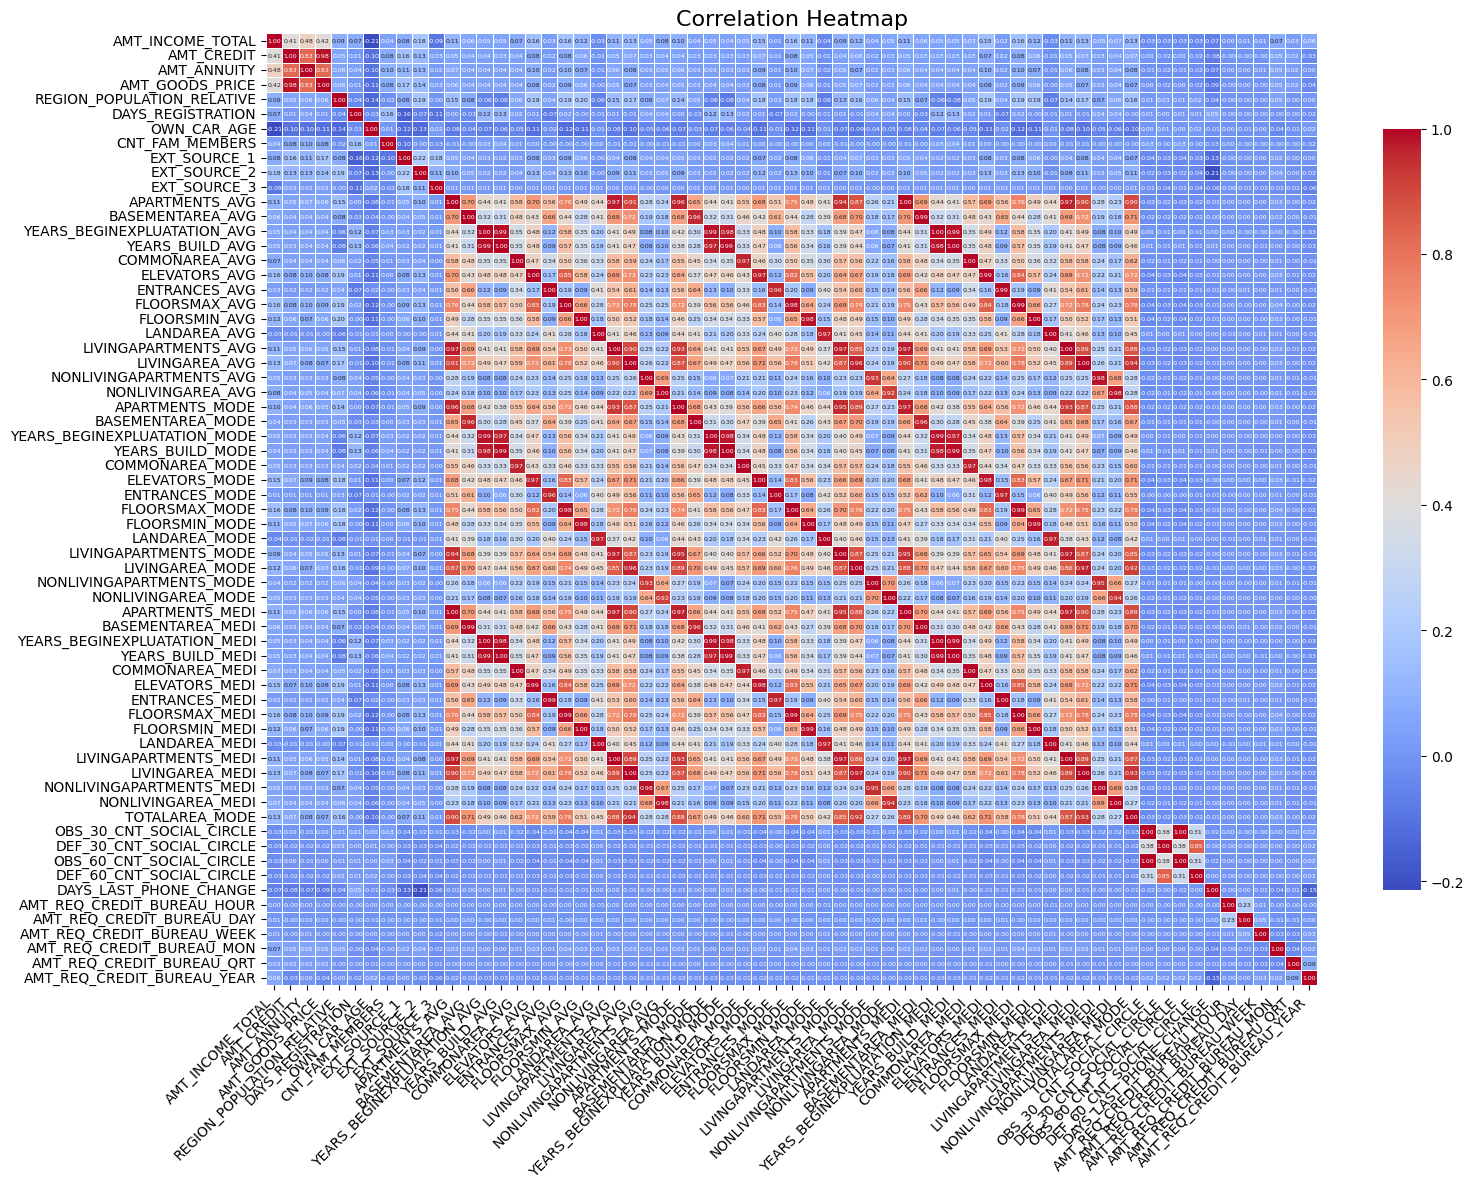

In [18]:
numerical_cols = [c for c in train.columns if train.loc[:, c].dtype in ('float',)]

corr = train[numerical_cols].corr(method = 'spearman')
plt.figure(figsize=(16,12))  # make heatmap larger

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=False,
    cbar_kws={"shrink": .8},
    annot_kws = {'size': 4.5}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Heatmap", fontsize=16)

plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3208264976.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="TARGET", data=train, palette="coolwarm")


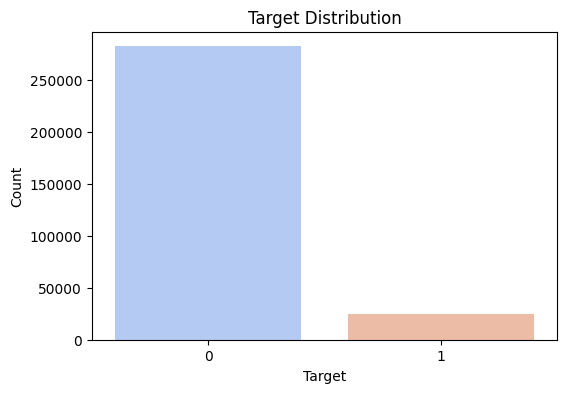

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="TARGET", data=train, palette="coolwarm")

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   48.4s finished


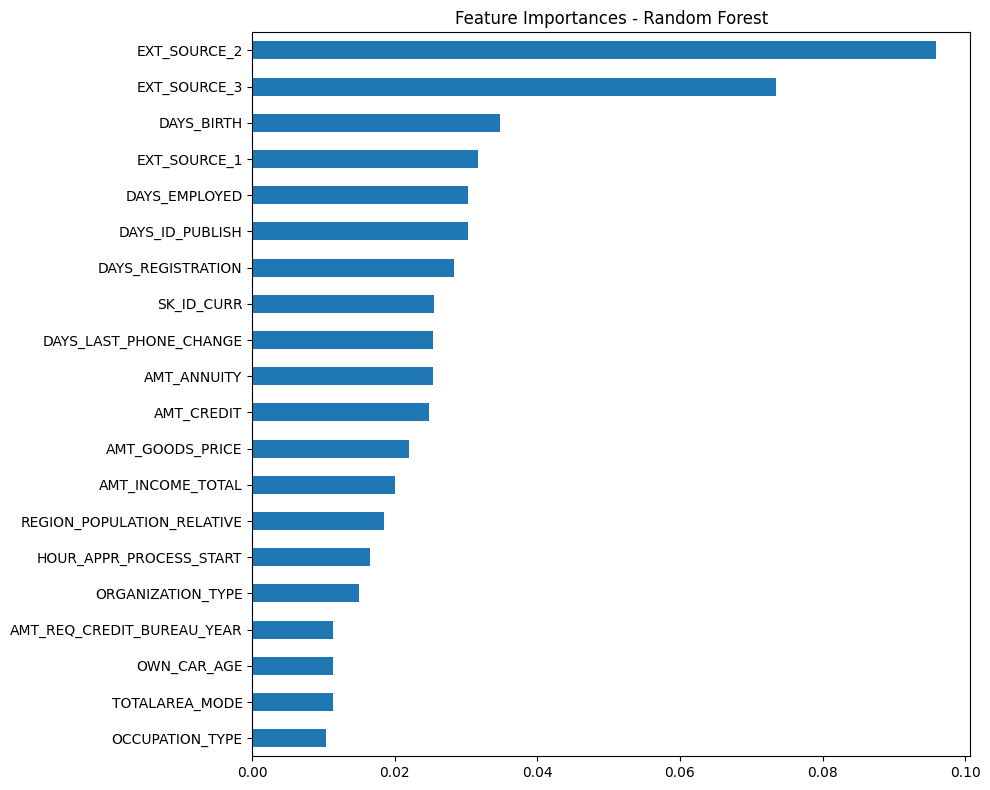

In [19]:
# Start by looking at which features actually matter - we will run this back at the very end again to see if feature engineering actually did anything

y = train['TARGET']
X = train.drop('TARGET', axis=1)

# Encode categoricals crudely
for col in X.select_dtypes('object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
X = X.fillna(-999)

rf = RandomForestClassifier(
    n_estimators=100,        
    max_depth=15,           
    max_samples=0.8,        
    n_jobs=-1,
    random_state=42,
    verbose = 1
)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(20).sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

## Main Dataset
This section includes:
- missing value processing
- feature engineering including interest rate
- some visualizations

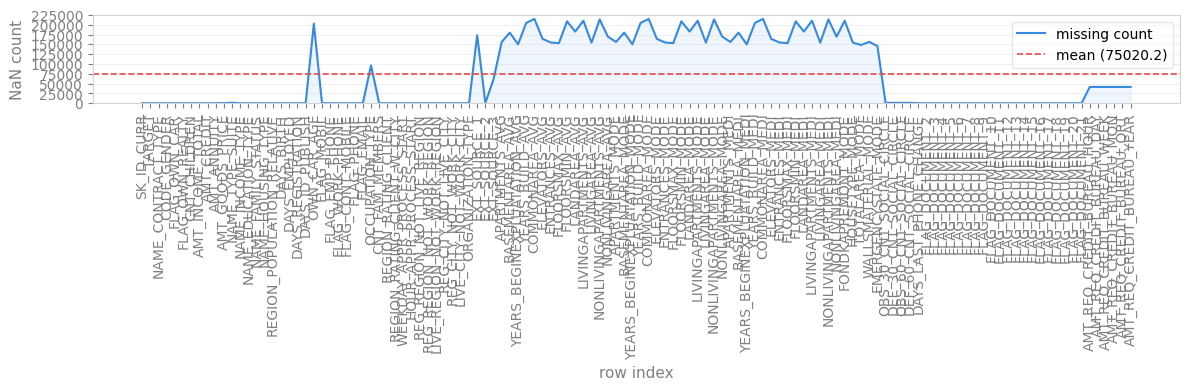

In [20]:
# Check missing values
missing = train.isna().sum()
mean_val = missing.mean()

fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(missing.index, missing.values, alpha=0.08, color="#378ADD")
ax.plot(missing.index, missing.values, color="#378ADD", linewidth=1.5, label="missing count")
ax.axhline(mean_val, color="#E24B4A", linewidth=1.2, linestyle="--", label=f"mean ({mean_val:.1f})")

ax.set_xlabel("row index", fontsize=11, color="gray")
ax.set_ylabel("NaN count", fontsize=11, color="gray")
ax.tick_params(colors="gray", labelsize=10)
ax.tick_params(axis='x', rotation=90)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(bottom=0)

for spine in ax.spines.values():
    spine.set_edgecolor("lightgray")
ax.grid(axis="y", color="lightgray", linewidth=0.5, alpha=0.5)
ax.set_facecolor("white")
ax.legend(fontsize=10, framealpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
# Columns missing significant portion of values
train.columns[train.isna().sum() > 25000].values

array(['OWN_CAR_AGE', 'OCCUPATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_3',
       'APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG',
       'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG',
       'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
       'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE',
       'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE',
       'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE',
       'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE',
       'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
       'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI',
       'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
       'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI',
       'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    

For these columns there are three cases:

1. Missing values due to sampling mistakes/ random noises
2. Missing values are strongly correlated with some other variables
3. Missing values are by itself a strong indicator

For 1 and 2 we can let xgboost do the work because it learns how to classify NaNs. For 3 we add a separate column that indicates a feature being missing.

In [22]:
train['OWN_CAR_AGE'] = train['OWN_CAR_AGE'].fillna(0)
train['OCCUPATION_TYPE'] = train['OCCUPATION_TYPE'].fillna('Unknown').astype('category')
train['EXT_SOURCE_1_missing'] = train['EXT_SOURCE_1'].isna().astype(int)
train['EXT_SOURCE_3_missing'] = train['EXT_SOURCE_3'].isna().astype(int)
housing_related_cols = ['APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG',
       'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG',
       'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
       'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE',
       'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE',
       'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE',
       'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE',
       'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
       'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI',
       'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
       'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI',
       'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
       'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI',
       'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE',
       'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
]
train['percentage_housing_missing'] = train[housing_related_cols].isna().sum(axis = 1) / len(housing_related_cols)
bureau_cols = ['AMT_REQ_CREDIT_BUREAU_HOUR',
        'AMT_REQ_CREDIT_BUREAU_DAY',
        'AMT_REQ_CREDIT_BUREAU_WEEK',
        'AMT_REQ_CREDIT_BUREAU_MON',
        'AMT_REQ_CREDIT_BUREAU_QRT',
        'AMT_REQ_CREDIT_BUREAU_YEAR'
]
train[bureau_cols] = train[bureau_cols].fillna(0)
train['BUREAU_REQUEST_TOTAL'] = (
    train['AMT_REQ_CREDIT_BUREAU_HOUR'] +
    train['AMT_REQ_CREDIT_BUREAU_DAY'] +
    train['AMT_REQ_CREDIT_BUREAU_WEEK'] +
    train['AMT_REQ_CREDIT_BUREAU_MON'] +
    train['AMT_REQ_CREDIT_BUREAU_QRT'] +
    train['AMT_REQ_CREDIT_BUREAU_YEAR']
)

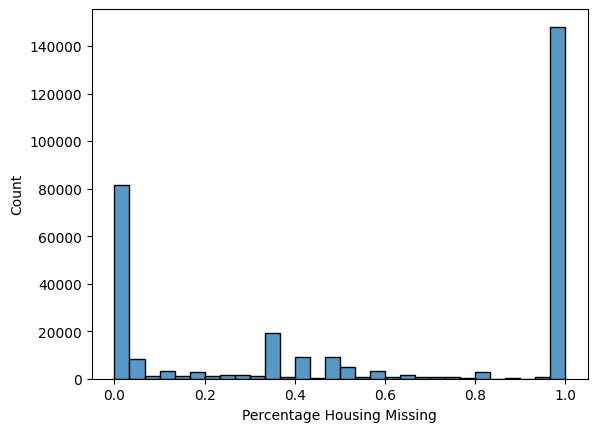

In [23]:
sns.histplot(train['percentage_housing_missing'], bins=30)
plt.xlabel('Percentage Housing Missing')
plt.show()

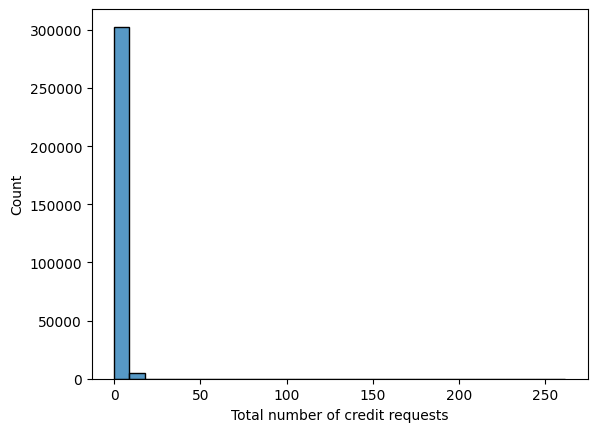

In [24]:
sns.histplot(train['BUREAU_REQUEST_TOTAL'], bins=30)
plt.xlabel('Total number of credit requests')
plt.show()

In [46]:
def interest_rate(row):
    P = row['AMT_CREDIT']
    A = row['AMT_ANNUITY']
    n = 60
    
    f = lambda r: A - P * r * (1+r)**n / ((1+r)**n - 1)
    r_solution = fsolve(f, 0.01)
    
    return r_solution[0]

train["ESTIMATED_RATE"] = train.apply(interest_rate, axis=1) # little slow due to fsolve

train['missing_days_employed'] = (train['DAYS_EMPLOYED'] == 365243).astype(int)
train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

train['EXT_SOURCE_MEAN'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis = 1)
train['EXT_SOURCE_PRODUCT'] = train['EXT_SOURCE_1'] * train['EXT_SOURCE_2'] * train['EXT_SOURCE_3']
train['EXT_SOURCE_STD'] = train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)

train['AGE_YEARS'] = -(train['DAYS_BIRTH'] / 365)
train['EMPLOYED_TO_AGE'] = train['DAYS_EMPLOYED'] / train['DAYS_BIRTH']

train['INCOME_PER_PERSON'] = train['AMT_INCOME_TOTAL'] / train['CNT_FAM_MEMBERS']
train['CREDIT_TO_INCOME_RATIO'] = train['AMT_CREDIT'] / train['AMT_INCOME_TOTAL']
train['ANNUITY_TO_INCOME_RATIO'] = train['AMT_ANNUITY'] / train['AMT_INCOME_TOTAL']

train['CREDIT_TO_ANNUITY_RATIO'] = train['AMT_CREDIT'] / train['AMT_ANNUITY']
train['CREDIT_TO_GOODS_RATIO'] = train['AMT_CREDIT'] / train['AMT_GOODS_PRICE']

train['CAR_TO_BIRTH_RATIO'] = train['OWN_CAR_AGE'] / train['AGE_YEARS']

/tmp/ipykernel_58/3534670365.py:7: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  r_solution = fsolve(f, 0.01)
/tmp/ipykernel_58/3534670365.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)


## Bureau

In [26]:
# bureau.csv
bureau = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/bureau.csv')

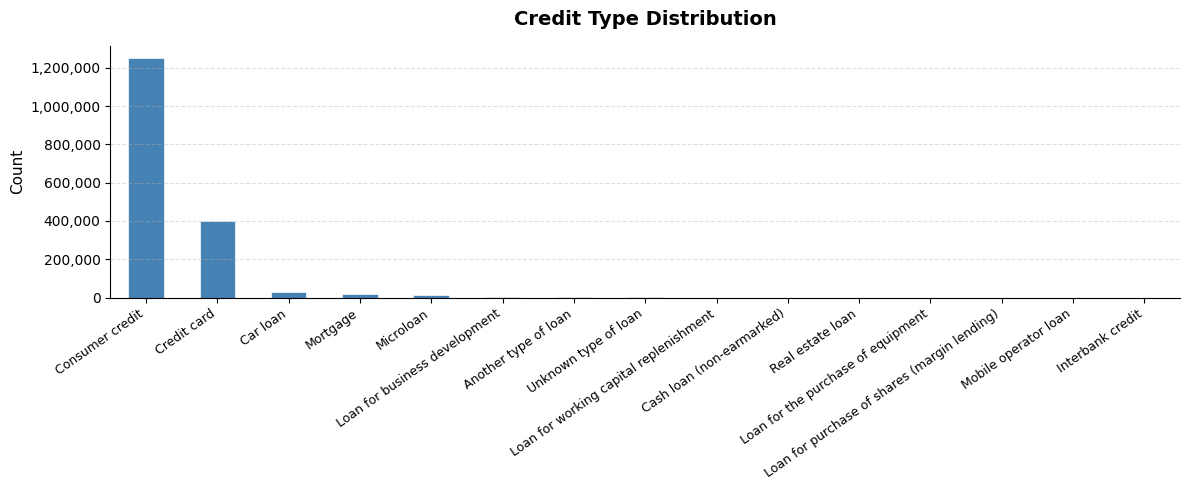

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

(
    bureau['CREDIT_TYPE']
    .value_counts()
    .plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', linewidth=0.5)
)

ax.set_title('Credit Type Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Count', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

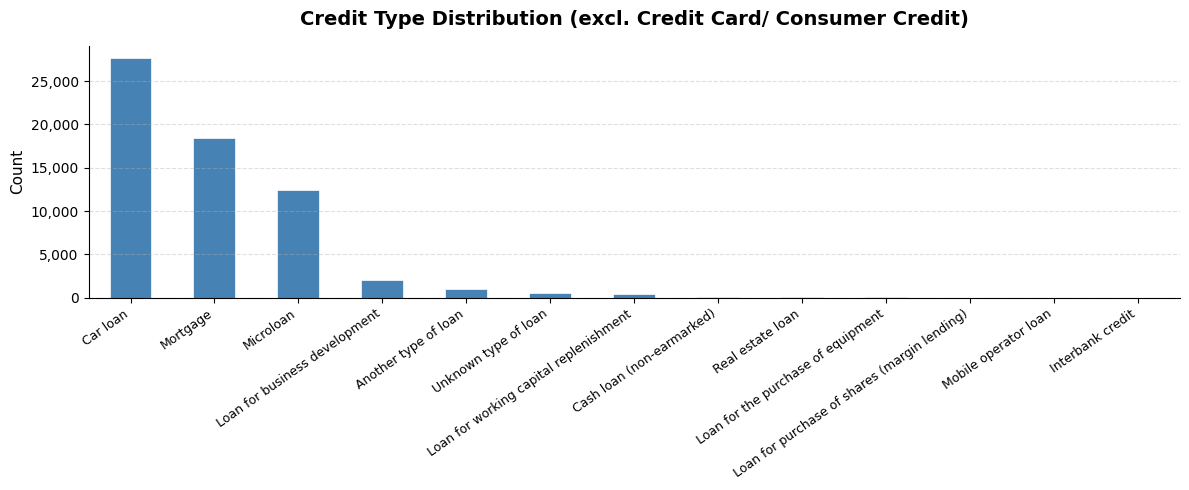

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))

(
    bureau
    .loc[(bureau['CREDIT_TYPE'] != 'Credit card') & (bureau['CREDIT_TYPE'] != 'Consumer credit'), 'CREDIT_TYPE']
    .value_counts()
    .plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', linewidth=0.5)
)

ax.set_title('Credit Type Distribution (excl. Credit Card/ Consumer Credit)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Count', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

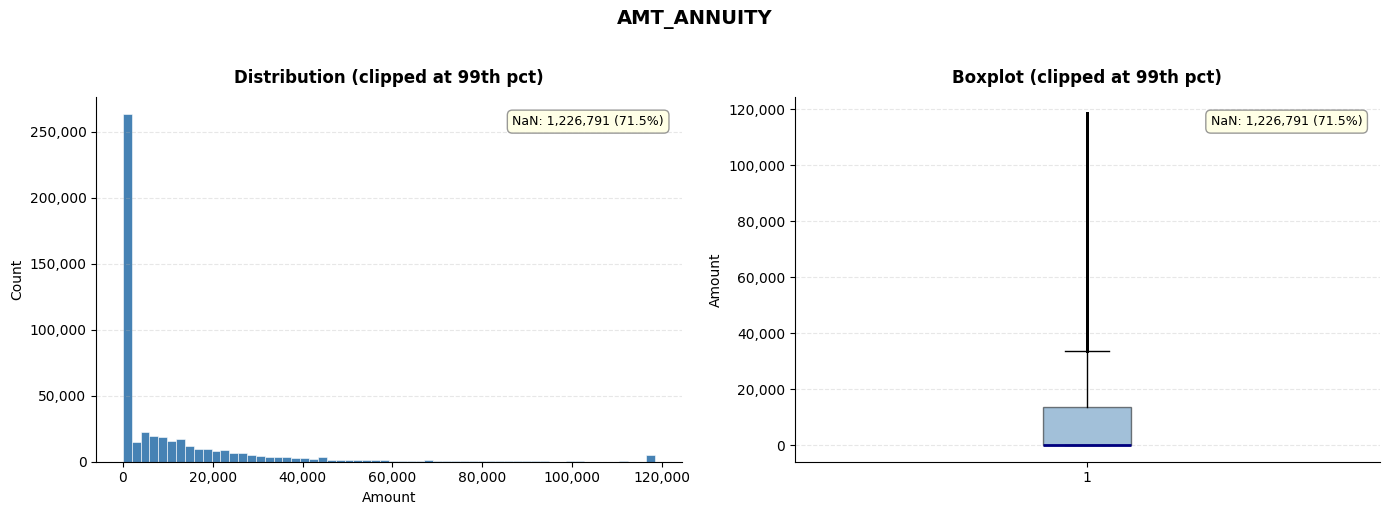

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

series = bureau["AMT_ANNUITY"].dropna()
nan_count = bureau["AMT_ANNUITY"].isna().sum()
nan_pct = nan_count / len(bureau) * 100

nan_label = f'NaN: {nan_count:,} ({nan_pct:.1f}%)'

# --- Left: histogram ---
ax = axes[0]
ax.hist(series.clip(upper=series.quantile(0.99)), bins=60, 
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Distribution (clipped at 99th pct)', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Amount')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.annotate(nan_label, xy=(0.97, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

# --- Right: boxplot ---
ax = axes[1]
ax.boxplot(series.clip(upper=series.quantile(0.99)), vert=True, 
           patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5),
           medianprops=dict(color='navy', linewidth=2),
           flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_title('Boxplot (clipped at 99th pct)', fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Amount')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.annotate(nan_label, xy=(0.97, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

plt.suptitle('AMT_ANNUITY', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [30]:
# Helper Columns
bureau['is_on_time'] = (
    bureau['DAYS_ENDDATE_FACT'].notna() & 
    (bureau['DAYS_ENDDATE_FACT'] <= bureau['DAYS_CREDIT_ENDDATE'])
)
bureau['is_overdue_obligation'] = bureau['DAYS_ENDDATE_FACT'] > bureau['DAYS_CREDIT_ENDDATE']
bureau['is_current_overdue_obligation'] = (bureau['DAYS_CREDIT_ENDDATE'] < 0) & (bureau['DAYS_ENDDATE_FACT'].isna())

bureau['is_active_consumer_loan'] = (bureau['DAYS_CREDIT_ENDDATE'] > 0) & (bureau['CREDIT_TYPE'].isin(['Consumer credit', 'Credit card']))
bureau['is_active_secured_loan'] = (bureau['DAYS_CREDIT_ENDDATE'] > 0) & (bureau['CREDIT_TYPE'].isin(['Mortgage', 'Car loan']))
bureau['is_active_business_loan'] = (bureau['DAYS_CREDIT_ENDDATE'] > 0) & (bureau['CREDIT_TYPE'].isin(['Microloan', ' Loan for working capital replenishment', 'Loan for business development']))

bureau['paid_credit'] = bureau['AMT_CREDIT_SUM'] - bureau['AMT_CREDIT_SUM_DEBT']
bureau['paid_to_borrowed_ratio'] = bureau['paid_credit'] / bureau['AMT_CREDIT_SUM']
bureau['paid_to_borrowed_ratio'] = bureau['paid_to_borrowed_ratio'].replace([np.inf], 1e9)
bureau['paid_to_borrowed_ratio'] = bureau['paid_to_borrowed_ratio'].clip(-1e9, 1e9)
bureau['unpaid_to_borrowed_ratio'] = bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM']
bureau['unpaid_to_borrowed_ratio'] = bureau['unpaid_to_borrowed_ratio'].replace([np.inf], 1e9)
bureau['unpaid_to_borrowed_ratio'] = bureau['unpaid_to_borrowed_ratio'].clip(-1e9, 1e9)
bureau['overdue_to_borrowed_ratio'] = bureau['AMT_CREDIT_SUM_OVERDUE'] / bureau['AMT_CREDIT_SUM']
bureau['overdue_to_borrowed_ratio'] = bureau['overdue_to_borrowed_ratio'].replace([np.inf], 1e9)
bureau['overdue_to_borrowed_ratio'] = bureau['overdue_to_borrowed_ratio'].clip(-1e9, 1e9)
bureau['interest_rate'] = 12 * bureau['AMT_ANNUITY'] / bureau['AMT_CREDIT_SUM']
bureau['interest_rate'] = bureau['interest_rate'].replace([np.inf], 1e9)
bureau['interest_rate'] = bureau['interest_rate'].clip(-1e9, 1e9)

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    
    # Number of loans in the past
    bureau_loan_count=('SK_ID_BUREAU', 'count'), 
    bureau_consumer_loan_count = ('CREDIT_TYPE', lambda x: (
        x.isin(['Consumer credit', 'Credit card'])
    ).sum()),
    bureau_secured_loan_count = ('CREDIT_TYPE', lambda x:(
        x.isin(['Mortgage', 'Car loan'])
    ).sum()),
    bureau_business_loan_count = ('CREDIT_TYPE', lambda x:(
        x.isin(['Microloan', 'Loan for working capital replenishment', 
                'Loan for business development'])
    ).sum()),
    
    # Number of active loans - by type
    bureau_active_loans=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    bureau_consumer_loan_active = ('is_active_consumer_loan', 'sum'),
    bureau_secured_loan_active = ('is_active_secured_loan', 'sum'),
    bureau_business_loan_active = ('is_active_business_loan', 'sum'),
    
    # Credit Currency
    bureau_currency_count = ('CREDIT_CURRENCY', 'nunique'),
    
    # Credit history - average age of loan, first loan, last loan, borrowing window
    # how much they borrowed in total, average loan size
    bureau_avg_days_credit=('DAYS_CREDIT', 'mean'),
    bureau_first_loan = ('DAYS_CREDIT', 'min'),
    bureau_last_loan = ('DAYS_CREDIT', 'max'),
    bureau_credit_window = ('DAYS_CREDIT', lambda x: x.max() - x.min()),
    bureau_total_borrowed = ('AMT_CREDIT_SUM', 'sum'),
    bureau_avg_loan_size = ('AMT_CREDIT_SUM', 'mean'),
    bureau_max_annuity = ('AMT_ANNUITY', 'max'),
    bureau_mean_paid_credit = ('paid_credit', 'mean'),
    bureau_sum_paid_credit = ('paid_credit', 'sum'),

    # Credit quality - number of overdue loans, percentage of overdue loans, longest overdue, 
    # maximum amount overdue, nmumber of overdue loans right now, number of extensions, 
    # maximum number of extensions on one debt, 
    bureau_longest_overdue = ('CREDIT_DAY_OVERDUE', 'max'),
    bureau_maximum_amount_overdue = ('AMT_CREDIT_MAX_OVERDUE', 'max'),
    bureau_max_extensions = ('CNT_CREDIT_PROLONG', 'max'),
    bureau_total_extensions_count = ('CNT_CREDIT_PROLONG', 'sum'),
    bureau_ontime_loans_count = ('is_on_time', 'sum'),
    bureau_overdue_loans_count = ('CREDIT_DAY_OVERDUE', lambda x: (x != 0).sum()),
    bureau_percentage_overdue = ('CREDIT_DAY_OVERDUE', lambda x: (x != 0).sum() / x.count()),
    bureau_current_overdue_loans_count = ('is_current_overdue_obligation', 'sum'),

    # Credit future - Number of pending loan deadline, total loan outstanding, 
    bureau_pending_loans_count = ('DAYS_CREDIT_ENDDATE', lambda x: (x > 0).sum()),
    bureau_oustanding_loan_total = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    bureau_total_current_overdue_loan = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),

    # Ratios
    bureau_paid_to_borrowed_ratio_mean = ('paid_to_borrowed_ratio', 'mean'),
    bureau_paid_to_borrowed_ratio_min = ('paid_to_borrowed_ratio', 'min'),
    bureau_unpaid_to_borrowed_ratio_mean = ('unpaid_to_borrowed_ratio', 'mean'),
    bureau_unpaid_to_borrowed_ratio_max = ('unpaid_to_borrowed_ratio', 'max'),
    bureau_overdue_to_borrowed_ratio_mean = ('overdue_to_borrowed_ratio', 'mean'),
    bureau_overdue_to_borrowed_ratio_max = ('overdue_to_borrowed_ratio', 'max'),
    bureau_interest_rate_mean = ('interest_rate', 'mean'),
    bureau_interest_rate_max = ('interest_rate', 'max')
).reset_index()

# total loan outstanding as a percent of total borrowed
bureau_agg['utilization'] = (
    bureau_agg['bureau_oustanding_loan_total'] / 
    bureau_agg['bureau_total_borrowed'].replace(0, np.nan)
).clip(upper=1)

In [31]:
# --- bureau_balance.csv ---
bb = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv')

In [32]:
default_statuses = {'1', '2', '3', '4', '5'}

bb_agg = bb.groupby('SK_ID_BUREAU').agg(
    # most recent default time on this loan
    # how bad did this loan ever went?
    # how many months did this person default on this loan?
    most_recent_default = ('MONTHS_BALANCE', lambda x: x[bb.loc[x.index, 'STATUS'].isin(default_statuses)].max()),
    worst_consecutive_default = ('STATUS', lambda x: x[x.isin(default_statuses)].astype(int).max() if x.isin(default_statuses).any() else 0),
    number_of_default_months = ('STATUS', lambda x: x.isin(default_statuses).sum())
).reset_index()

# Aggregate: min(most_recent_default), max(worst_state), max(worst_default_count_months)

In [33]:
bureau_bb = bureau[['SK_ID_CURR', 'SK_ID_BUREAU']].merge(bb_agg, on='SK_ID_BUREAU')
bureau_bb_agg = bureau_bb.groupby('SK_ID_CURR').agg(
    most_recent_default = ('most_recent_default', 'max'),
    worst_consecutive_default = ('worst_consecutive_default', 'max'),
    number_of_default_months = ('number_of_default_months', 'sum')
).reset_index()

## Previous Application

In [34]:
# --- previous_application.csv ---
prev = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/previous_application.csv')
prev.replace(365243, np.nan, inplace=True)

In [36]:
prev['NAME_CASH_LOAN_PURPOSE'].value_counts()

NAME_CASH_LOAN_PURPOSE
XAP                                 922661
XNA                                 677918
Repairs                              23765
Other                                15608
Urgent needs                          8412
Buying a used car                     2888
Building a house or an annex          2693
Everyday expenses                     2416
Medicine                              2174
Payments on other loans               1931
Education                             1573
Journey                               1239
Purchase of electronic equipment      1061
Buying a new car                      1012
Wedding / gift / holiday               962
Buying a home                          865
Car repairs                            797
Furniture                              749
Buying a holiday home / land           533
Business development                   426
Gasification / water supply            300
Buying a garage                        136
Hobby                          

In [37]:
prev['APP_CREDIT_DIFF'] = prev['AMT_APPLICATION'] - prev['AMT_CREDIT']
prev['APP_CREDIT_RATIO'] = prev['AMT_CREDIT'] / prev['AMT_APPLICATION']
prev.loc[prev['APP_CREDIT_RATIO'] > 1e9, 'APP_CREDIT_RATIO'] = np.nan

prev['DOWN_PAYMENT_RATIO'] = prev['AMT_DOWN_PAYMENT'] / prev['AMT_CREDIT']

prev['CREDIT_PER_PAYMENT'] = prev['AMT_CREDIT'] / prev['CNT_PAYMENT']
prev['CREDIT_PER_PAYMENT'] = prev['CREDIT_PER_PAYMENT'].replace([np.inf], 1e9)
prev['CREDIT_PER_PAYMENT'] = prev['CREDIT_PER_PAYMENT'].clip(-1e9, 1e9)

prev['GOODS_CREDIT_RATIO'] = prev['AMT_GOODS_PRICE'] / prev['AMT_CREDIT']
prev['GOODS_CREDIT_RATIO'] = prev['GOODS_CREDIT_RATIO'].replace([np.inf], 1e9)
prev['GOODS_CREDIT_RATIO'] = prev['GOODS_CREDIT_RATIO'].clip(-1e9, 1e9)

In [38]:
prev_agg = prev.groupby('SK_ID_CURR').agg(
    count = ('AMT_APPLICATION', 'count'),
    approval_count = ('NAME_CONTRACT_STATUS', lambda x: (x=='Approved').sum()),
    rejection_count = ('NAME_CONTRACT_STATUS', lambda x: (x=='Refused').sum()),
    cancel_count = ('NAME_CONTRACT_STATUS', lambda x: (x=='Canceled').sum()),
    unused_count = ('NAME_CONTRACT_STATUS', lambda x: (x=='Unused offer').sum()),
    avg_amount_applied = ('AMT_APPLICATION', 'mean'),
    max_amount_applied = ('AMT_APPLICATION', 'max'),
    avg_credit_received = ('AMT_CREDIT', 'mean'),
    max_credit_received = ('AMT_CREDIT', 'max'),
    avg_annuity = ('AMT_ANNUITY', 'mean'),
    cnt_payment_mean = ('CNT_PAYMENT', 'mean'),
    cnt_payment_max = ('CNT_PAYMENT', 'max'),
    app_credit_diff = ('APP_CREDIT_DIFF', 'mean'),
    app_credit_ratio = ('APP_CREDIT_RATIO', 'mean'),
    credit_per_payment = ('CREDIT_PER_PAYMENT', 'mean'),
    down_payment_ratio = ('DOWN_PAYMENT_RATIO', 'mean'),
    days_decision_min = ('DAYS_DECISION', 'min'),
    days_decision_mean = ('DAYS_DECISION', 'mean'),
    days_decision_max = ('DAYS_DECISION', 'max'),
    goods_to_credit_mean = ('GOODS_CREDIT_RATIO', 'mean'),
    goods_to_credit_max = ('GOODS_CREDIT_RATIO', 'max'),
)
prev_agg['approval_rate'] = prev_agg['approval_count'] / prev_agg['count']
prev_agg['approval_to_rejection'] = prev_agg['approval_count'] / prev_agg['rejection_count'].replace(0, np.nan)

## Loan Payment 

In [39]:
pos = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv')
pos['INSTALMENT_RATIO'] = pos['CNT_INSTALMENT_FUTURE'] / pos['CNT_INSTALMENT']
pos['IS_DPD'] = (pos['SK_DPD'] > 0).astype(int)
pos['IS_DPD_DEF'] = (pos['SK_DPD_DEF'] > 0).astype(int)
pos['IS_DPD_30'] = (pos['SK_DPD'] > 30).astype(int)

In [40]:
pos_agg = pos.groupby('SK_ID_CURR').agg(
    pos_count=('SK_ID_PREV','count'),

    months_balance_min=('MONTHS_BALANCE','min'),
    months_balance_max=('MONTHS_BALANCE','max'),

    #cnt_instalment_mean=('CNT_INSTALMENT','mean'),
    #cnt_instalment_future_mean=('CNT_INSTALMENT_FUTURE','mean'),

    #instalment_ratio_mean=('INSTALMENT_RATIO','mean'),

    dpd_mean=('SK_DPD','mean'),
    dpd_max=('SK_DPD','max'),

    dpd_def_mean=('SK_DPD_DEF','mean'),
    dpd_def_max=('SK_DPD_DEF','max'),

    dpd_flag_rate=('IS_DPD','mean'),
    dpd_def_flag_rate=('IS_DPD_DEF','mean'),
    dpd_30_rate=('IS_DPD_30','mean')
)
# pos_agg['pos_completed_ratio'] = (
#     pos_agg['cnt_instalment_future_mean'] /
#     pos_agg['cnt_instalment_mean']
# )

## Installment

In [54]:
installment = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv')
installment['days_late_or_early'] = installment['DAYS_ENTRY_PAYMENT'] - installment['DAYS_INSTALMENT']
installment['payment_ratio'] = installment['AMT_PAYMENT'] / installment['AMT_INSTALMENT']
installment['payment_ratio'] = installment['payment_ratio'].clip(-1e9, 1e9)

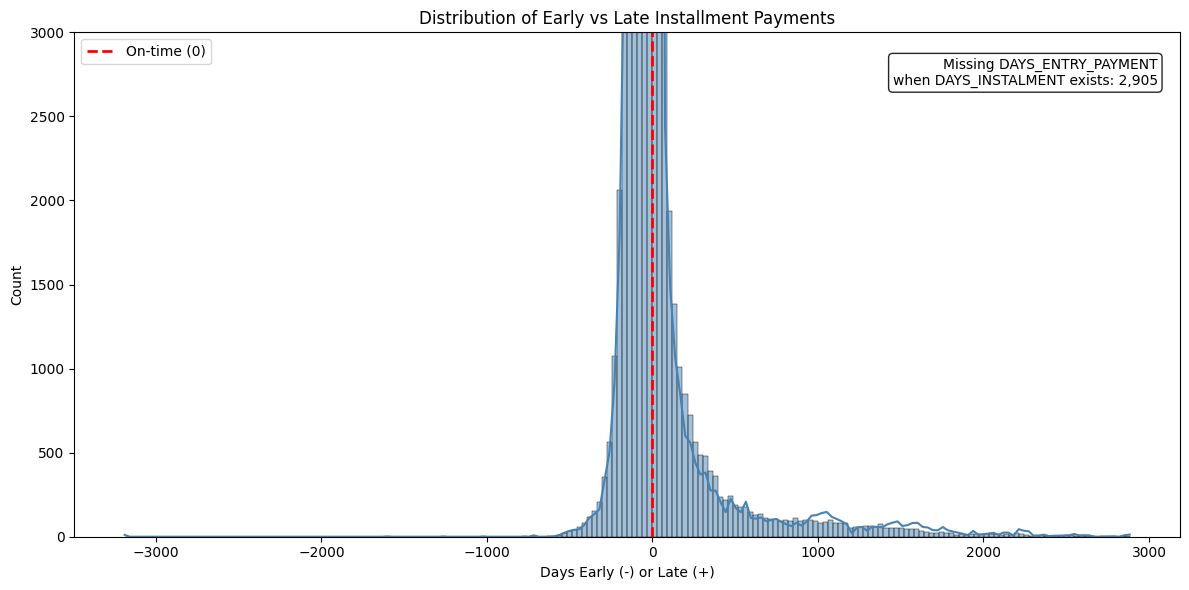

In [55]:
null_payment_count = installment[
    installment['DAYS_ENTRY_PAYMENT'].isna() & installment['DAYS_INSTALMENT'].notna()
].shape[0]

plot_data = installment['days_late_or_early'].dropna()
plot_data = plot_data[plot_data != 0]

plt.figure(figsize=(12,6))

sns.histplot(
    plot_data,
    bins=200,
    kde=True,
    color='steelblue'
)

plt.axvline(0, color='red', linestyle='--', linewidth=2, label='On-time (0)')

plt.title('Distribution of Early vs Late Installment Payments')
plt.xlabel('Days Early (-) or Late (+)')
plt.ylabel('Count')

plt.text(
    0.98, 0.95,
    f"Missing DAYS_ENTRY_PAYMENT\nwhen DAYS_INSTALMENT exists: {null_payment_count:,}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
)
plt.ylim(0, 3000)

plt.legend()
plt.tight_layout()
plt.show()

In [56]:
installment_agg = installment.groupby('SK_ID_CURR').agg(
    avg_late_time = ('days_late_or_early', 'mean'),
    max_late_time = ('days_late_or_early', 'max'),
    max_early_time = ('days_late_or_early', 'min'),
    mean_payment_ratio = ('payment_ratio', 'mean'),
    worst_payment_ratio = ('payment_ratio', 'min'),
    total_installment = ('SK_ID_PREV', 'count'),
    total_paid = ('AMT_PAYMENT', 'sum'),
)

## Credit Card Balance

In [57]:
credit_card_balance = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv')
credit_card_balance['utilization'] = credit_card_balance['AMT_BALANCE'] / credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL']
credit_card_balance['utilization'] = credit_card_balance['utilization'].clip(-1e9, 1e9)
credit_card_balance['payment_ratio'] = credit_card_balance['AMT_PAYMENT_CURRENT'] / credit_card_balance['AMT_INST_MIN_REGULARITY']
credit_card_balance['payment_ratio'] = credit_card_balance['payment_ratio'].clip(-1e9, 1e9)

credit_card_balance['ATM_to_total_drawn'] = credit_card_balance['AMT_DRAWINGS_ATM_CURRENT'] / credit_card_balance['AMT_DRAWINGS_CURRENT']
credit_card_balance['ATM_to_total_drawn'] = credit_card_balance['ATM_to_total_drawn'].clip(-1e9, 1e9)
credit_card_balance['POS_to_total_drawn'] = credit_card_balance['AMT_DRAWINGS_POS_CURRENT'] / credit_card_balance['AMT_DRAWINGS_CURRENT']
credit_card_balance['POS_to_total_drawn'] = credit_card_balance['POS_to_total_drawn'].clip(-1e9, 1e9)

credit_card_balance['interest+fee'] = credit_card_balance['AMT_RECIVABLE'] - credit_card_balance['AMT_RECEIVABLE_PRINCIPAL']

In [58]:
credit_card_agg = credit_card_balance.groupby('SK_ID_CURR').agg(
    utiliztion_mean = ('utilization', 'mean'),
    utiliztion_max = ('utilization', 'max'),
    payment_ratio_mean = ('payment_ratio', 'mean'),
    ATM_to_total_drawn_mean = ('ATM_to_total_drawn', 'mean'),
    POS_to_total_drawn_mean = ('POS_to_total_drawn', 'mean'),
    total_draw_amount = ('AMT_DRAWINGS_CURRENT', 'sum'),
    total_drawn_ATM = ('AMT_DRAWINGS_ATM_CURRENT', 'sum'),
    total_drawn_POS = ('AMT_DRAWINGS_POS_CURRENT', 'sum'),
    total_paid = ('AMT_PAYMENT_CURRENT', 'sum'),
    mean_paid = ('AMT_PAYMENT_CURRENT', 'mean'),
    total_ATM_count = ('CNT_DRAWINGS_ATM_CURRENT', 'sum'),
    total_POS_count = ('CNT_DRAWINGS_POS_CURRENT', 'sum'),
    total_count = ('CNT_DRAWINGS_CURRENT', 'sum')
)

# Final Processing + Training + Results

## Final Processing + Training
This section includes:
- encoding non-numerical data
- last minute feature engineering
- training an XGBoost + RandomGrid search for best parameters

In [62]:
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')
train = train.merge(bureau_bb_agg, on='SK_ID_CURR', how='left')
train = train.merge(prev_agg, on='SK_ID_CURR', how='left')
train['PAYMENT_TO_INCOME'] = train['avg_annuity'] / train['AMT_INCOME_TOTAL']
train = train.merge(pos_agg, on='SK_ID_CURR', how='left')
train = train.merge(installment_agg, on='SK_ID_CURR', how='left')
train = train.merge(credit_card_agg, on='SK_ID_CURR', how='left')

In [63]:
train.shape

(307511, 235)

In [64]:
non_number_cols = [cols for cols in train.columns if train.loc[:, cols].dtype not in (int, float)]
train.loc[5:10, non_number_cols]

,NAME_CONTRACT_TYPE,CODE_GENDER,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
5,Cash loans,M,"Spouse, partner",State servant,Married,House / apartment,Laborers,Other,NaN,NaN,NaN,NaN
6,Cash loans,F,Unaccompanied,Commercial associate,Married,House / apartment,Accountants,Business Entity Type 3,NaN,NaN,NaN,NaN
7,Cash loans,M,Unaccompanied,State servant,Married,House / apartment,Managers,Other,NaN,NaN,NaN,NaN
8,Cash loans,F,Children,Pensioner,Married,House / apartment,Unknown,XNA,NaN,NaN,NaN,NaN
9,Revolving loans,M,Unaccompanied,Working,Single / not married,House / apartment,Laborers,Electricity,NaN,NaN,NaN,NaN
10,Cash loans,F,Unaccompanied,Working,Married,House / apartment,Core staff,Medicine,NaN,NaN,NaN,NaN


In [65]:
OneHotCols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE', 
              'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 
              'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',	
              'HOUSETYPE_MODE',	'WALLSMATERIAL_MODE',	'EMERGENCYSTATE_MODE'
             ]
LabelCols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 
             'WEEKDAY_APPR_PROCESS_START'
            ]
label_maps = {
    'FLAG_OWN_CAR': {'Y':1, 'N':0},
    'FLAG_OWN_REALTY': {'Y':1, 'N':0},
    'NAME_EDUCATION_TYPE': {
        'Lower secondary':0,
        'Secondary / secondary special':1,
        'Incomplete higher':2,
        'Higher education':3,
        'Academic degree':4
    },
    'WEEKDAY_APPR_PROCESS_START': {
        'MONDAY':1,'TUESDAY':2,'WEDNESDAY':3,'THURSDAY':4,
        'FRIDAY':5,'SATURDAY':6,'SUNDAY':7
    }
}
for col, mapping in label_maps.items():
    train[col] = train[col].map(mapping)

train_encoded = pd.get_dummies(train, columns = OneHotCols)

In [66]:
train_encoded.to_csv('/kaggle/working/train_final.csv') # this processed dataset is used as a baseline for my other notebooks

In [68]:
y = train_encoded['TARGET']
X = train_encoded.drop(['TARGET', 'SK_ID_CURR'], axis=1)
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].astype('category')

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    early_stopping = 25,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50
)

# base_model = XGBClassifier(
#     enable_categorical=True,
#     tree_method='hist',
#     eval_metric='auc',
#     random_state=42,
#     n_jobs=-1
# )

# param_dist = {
#     "n_estimators": randint(300, 1200),
#     "learning_rate": uniform(0.01, 0.09),
#     "max_depth": randint(4, 12),
#     "min_child_weight": randint(1, 10),
#     "subsample": uniform(0.6, 0.4),
#     "colsample_bytree": uniform(0.6, 0.4),
#     "gamma": uniform(0, 5),
#     "reg_alpha": uniform(0, 1),
#     "reg_lambda": uniform(0.5, 2)
# }

# search = RandomizedSearchCV(
#     estimator=base_model,
#     param_distributions=param_dist,
#     n_iter=50,
#     scoring="roc_auc",
#     cv=3,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

# search.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_val, y_val)],
#     verbose=False
# )

# best_model = search.best_estimator_

# print("Best params:", search.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:04:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "early_stopping" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-auc:0.72841
[50]	validation_0-auc:0.76953
[100]	validation_0-auc:0.77969
[150]	validation_0-auc:0.78342
[200]	validation_0-auc:0.78552
[250]	validation_0-auc:0.78732
[300]	validation_0-auc:0.78844
[350]	validation_0-auc:0.78942
[400]	validation_0-auc:0.78992
[450]	validation_0-auc:0.79038
[500]	validation_0-auc:0.79059
[550]	validation_0-auc:0.79073
[600]	validation_0-auc:0.79076
[650]	validation_0-auc:0.79085
[699]	validation_0-auc:0.79099


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping=25,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=700, n_jobs=None, ...)

## Results

This section includes
- ROC curve
- Precision-recall curve
- Confusion matrix
- SHAP summary plot
- Random Forest feature importance (to see if feature engineering did anything)
- Model comparison table: logistic regression vs random forest vs LightGBM / XGBoost (our model of choice) / CatBoost

To see more advanced results, check out https://www.kaggle.com/code/leoliu1415/time-series-on-home-credit where I used deep learning features to enhance the model

In [69]:
y_pred = model.predict(X_valid)
y_prob = model.predict_proba(X_valid)[:,1]

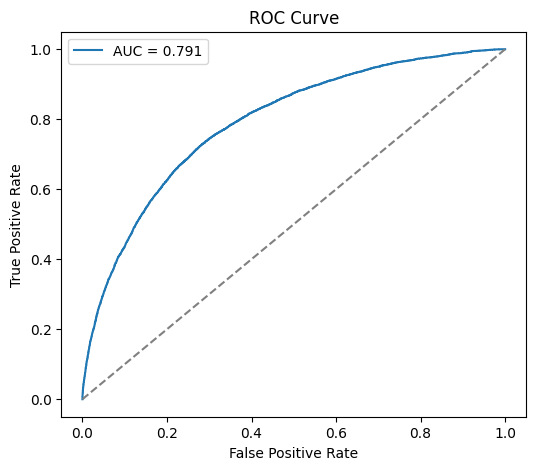

In [72]:
fpr, tpr, _ = roc_curve(y_valid, y_prob)
roc_auc = roc_auc_score(y_valid, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

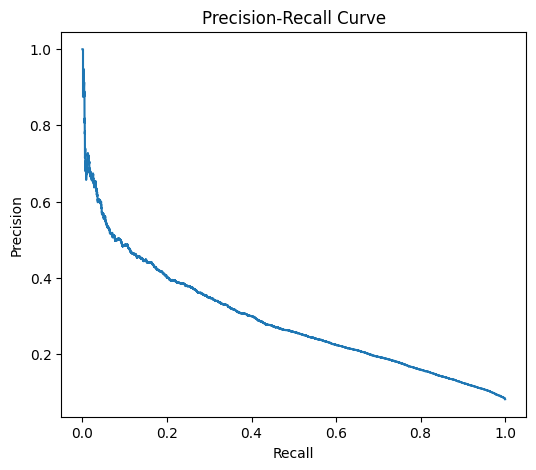

In [73]:
precision, recall, _ = precision_recall_curve(y_valid, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

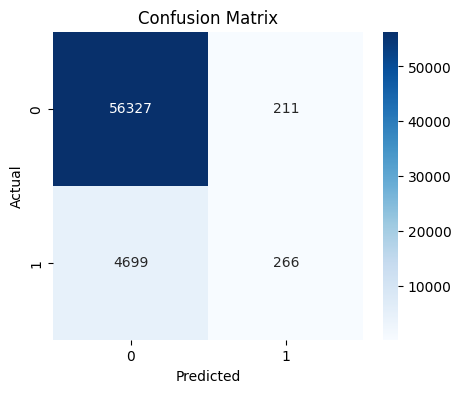

In [74]:
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

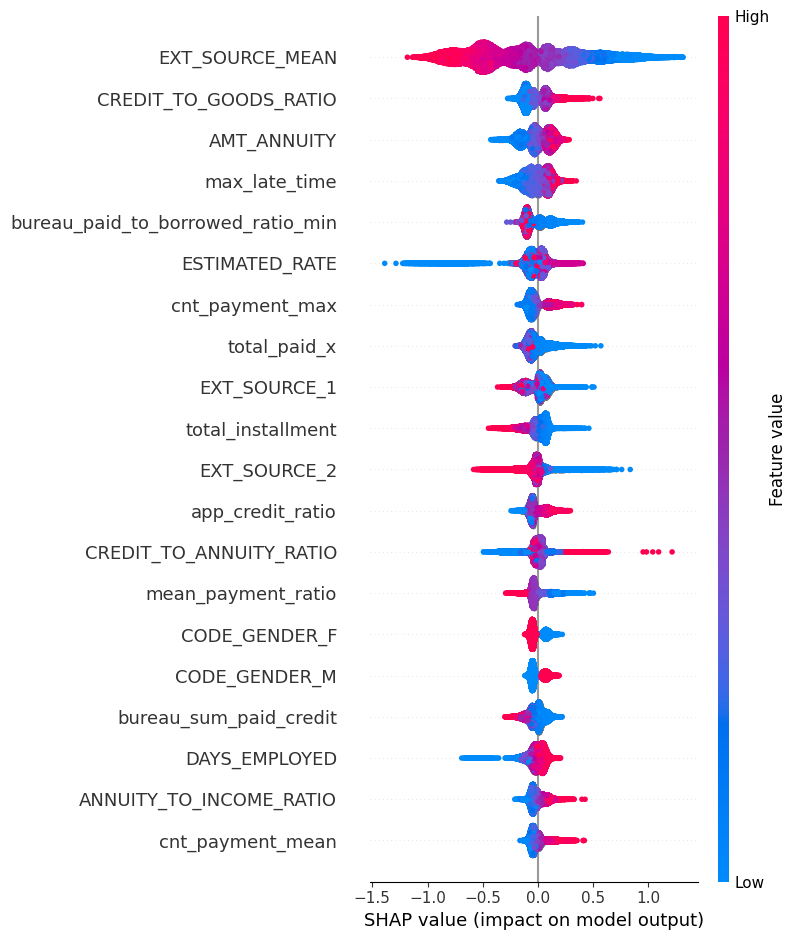

In [75]:
import shap # see if feature engineering actually did anything

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_valid)

shap.summary_plot(shap_values, X_valid)

Notice the majority of the features here are engineered features, suggesting that feature engineering has been successful in providing useful signals